# COVID-19 Data Analysis and Visualization 



## 1. Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')   # Background

## 2. Load the dataset



In [ ]:
df = pd.read_csv('COVID-19 Dataset.csv')

df.head()

,Date,Country,Region,Population,New_Cases,Cumulative_Cases,New_Recovered,Cumulative_Recovered,New_Deaths,Cumulative_Deaths,Active_Cases,New_Vaccinations,Cumulative_Vaccinations,Government_Intervention_Score,Case_Fatality_Rate_Percent,Recovery_Rate_Percent
0,01-01-2020,United States,North America,331000000,46085,46085,37136,37136,688,688,8261,0,0,51,1.49,80.58
1,02-01-2020,United States,North America,331000000,59357,105442,49591,86727,843,1531,17184,0,0,51,1.45,82.25
2,03-01-2020,United States,North America,331000000,58661,164103,50457,137184,903,2434,24485,0,0,55,1.48,83.60
3,04-01-2020,United States,North America,331000000,66595,230698,57627,194811,767,3201,32686,0,0,47,1.39,84.44
4,05-01-2020,United States,North America,331000000,49759,280457,42918,237729,565,3766,38962,0,0,52,1.34,84.76


In [ ]:
print('Rows and columns:', df.shape)

print(df.columns.tolist())

Rows and columns: (10000, 16)
['Date', 'Country', 'Region', 'Population', 'New_Cases', 'Cumulative_Cases', 'New_Recovered', 'Cumulative_Recovered', 'New_Deaths', 'Cumulative_Deaths', 'Active_Cases', 'New_Vaccinations', 'Cumulative_Vaccinations', 'Government_Intervention_Score', 'Case_Fatality_Rate_Percent', 'Recovery_Rate_Percent']


## 3. Understand the data

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           10000 non-null  str    
 1   Country                        10000 non-null  str    
 2   Region                         10000 non-null  str    
 3   Population                     10000 non-null  int64  
 4   New_Cases                      10000 non-null  int64  
 5   Cumulative_Cases               10000 non-null  int64  
 6   New_Recovered                  10000 non-null  int64  
 7   Cumulative_Recovered           10000 non-null  int64  
 8   New_Deaths                     10000 non-null  int64  
 9   Cumulative_Deaths              10000 non-null  int64  
 10  Active_Cases                   10000 non-null  int64  
 11  New_Vaccinations               10000 non-null  int64  
 12  Cumulative_Vaccinations        10000 non-null  int64  
 13

In [59]:
df.describe()

,Population,New_Cases,Cumulative_Cases,New_Recovered,Cumulative_Recovered,New_Deaths,Cumulative_Deaths,Active_Cases,New_Vaccinations,Cumulative_Vaccinations,Government_Intervention_Score,Case_Fatality_Rate_Percent,Recovery_Rate_Percent
count,1.000000e+04,10000.000000,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.00000,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,2.391000e+08,29551.195000,1.264003e+07,24953.366300,1.067773e+07,340.361100,140753.23530,1.821538e+06,1.352753e+06,3.536160e+08,44.499100,1.101740,84.538321
std,3.905306e+08,27873.983936,1.404904e+07,23648.300465,1.186184e+07,348.617605,159074.91818,2.030556e+06,3.228617e+06,1.025181e+09,16.196556,0.127392,1.606459
min,2.600000e+07,1476.000000,3.780000e+03,1101.000000,3.158000e+03,13.000000,44.00000,3.800000e+02,0.000000e+00,0.000000e+00,0.000000,0.670000,71.690000
25%,6.000000e+07,10724.500000,3.030626e+06,9068.750000,2.578197e+06,113.000000,32053.75000,4.264568e+05,0.000000e+00,0.000000e+00,31.000000,1.050000,83.930000
50%,7.550000e+07,20273.000000,7.629806e+06,17059.000000,6.465339e+06,223.000000,83227.00000,1.069978e+06,3.265715e+05,3.499249e+07,45.000000,1.110000,84.500000
75%,2.130000e+08,37755.250000,1.665396e+07,32039.500000,1.405835e+07,435.000000,185653.50000,2.408408e+06,9.272710e+05,2.356041e+08,58.000000,1.160000,85.130000
max,1.380000e+09,233974.000000,7.496144e+07,218998.000000,6.320863e+07,2797.000000,865760.00000,1.088705e+07,1.984708e+07,7.969879e+09,91.000000,1.670000,93.040000


In [ ]:
print('Missing values :', df.isnull().sum().sum())

print('Duplicate rows :', df.duplicated().sum())

print('Countries      :', list(df['Country'].unique()))

print('Regions        :', list(df['Region'].unique()))

Missing values : 0
Duplicate rows : 0
Countries      : ['United States', 'India', 'Brazil', 'United Kingdom', 'Germany', 'France', 'Italy', 'Canada', 'Japan', 'Australia']
Regions        : ['North America', 'Asia', 'South America', 'Europe', 'Oceania']


## 4. Prepare the data



In [ ]:
# 1. convert Date to a real date
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')



# 2. sort by country and date
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)



# 3. new date columns
df['Year'] = df['Date'].dt.year

df['Month'] = df['Date'].dt.month

df['Year_Month'] = df['Date'].dt.strftime('%Y-%m')



# 4. cases and deaths per million people
df['Cases_per_Million'] = df['New_Cases'] / df['Population'] * 1000000

df['Deaths_per_Million'] = df['New_Deaths'] / df['Population'] * 1000000



# 5. intervention level: Low, Medium or High
df['Intervention_Level'] = pd.cut(df['Government_Intervention_Score'],
                                  
                                  bins=[-1, 30, 60, 100],
                                  
                                  labels=['Low', 'Medium', 'High'])



# 6. last day only = final totals
last_day = df[df['Date'] == df['Date'].max()]

last_day[['Country', 'Region', 'Population', 'Cumulative_Cases', 'Cumulative_Recovered', 'Cumulative_Deaths']]

,Country,Region,Population,Cumulative_Cases,Cumulative_Recovered,Cumulative_Deaths
999,Australia,Oceania,26000000,6939510,5892629,77992
1999,Brazil,South America,213000000,47133678,39887534,537499
2999,Canada,North America,38000000,10308184,8758404,116994
3999,France,Europe,68000000,23830173,20144426,274506
4999,Germany,Europe,83000000,20534116,17300738,238123
5999,India,Asia,1380000000,52953754,44674419,618116
6999,Italy,Europe,60000000,18045039,15170311,209977
7999,Japan,Asia,125000000,15968289,13576609,177126
8999,United Kingdom,Europe,67000000,24837765,20919959,287518
9999,United States,North America,331000000,74961442,63208634,865760


## 5. Line charts 

### 5.1 Daily new cases, recoveries and deaths

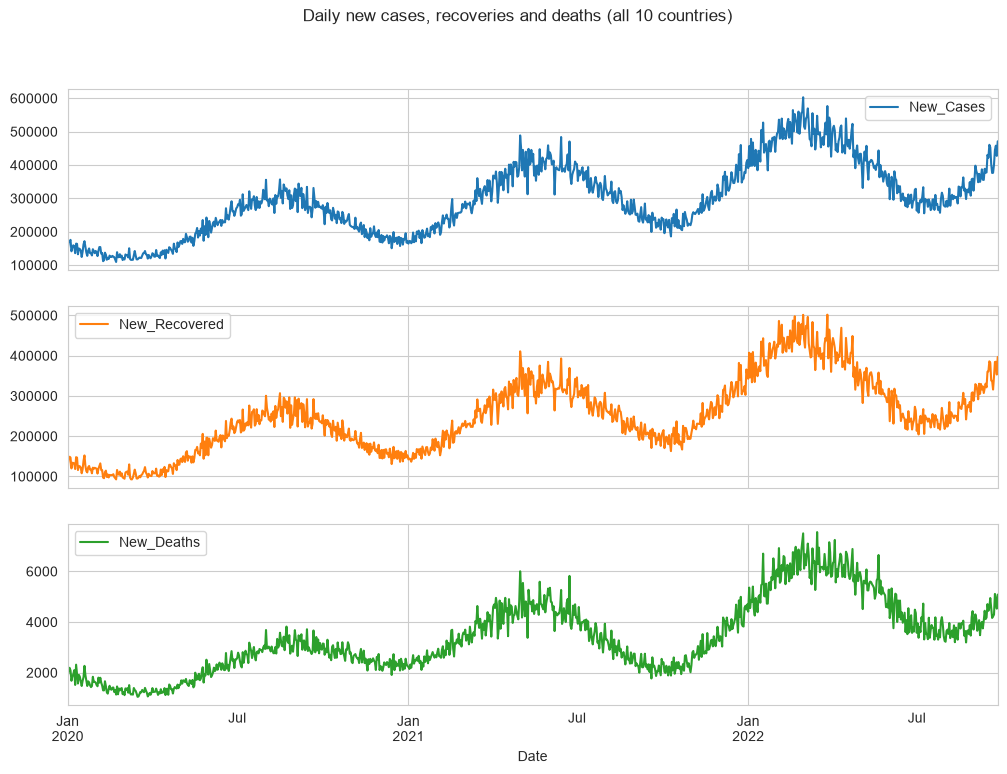

In [ ]:
daily = df.groupby('Date')[['New_Cases', 'New_Recovered', 'New_Deaths']].sum()

daily.plot(subplots=True, figsize=(12, 8), title='Daily new cases, recoveries and deaths (all 10 countries)')

plt.show()

### 5.2 Average daily new cases per month

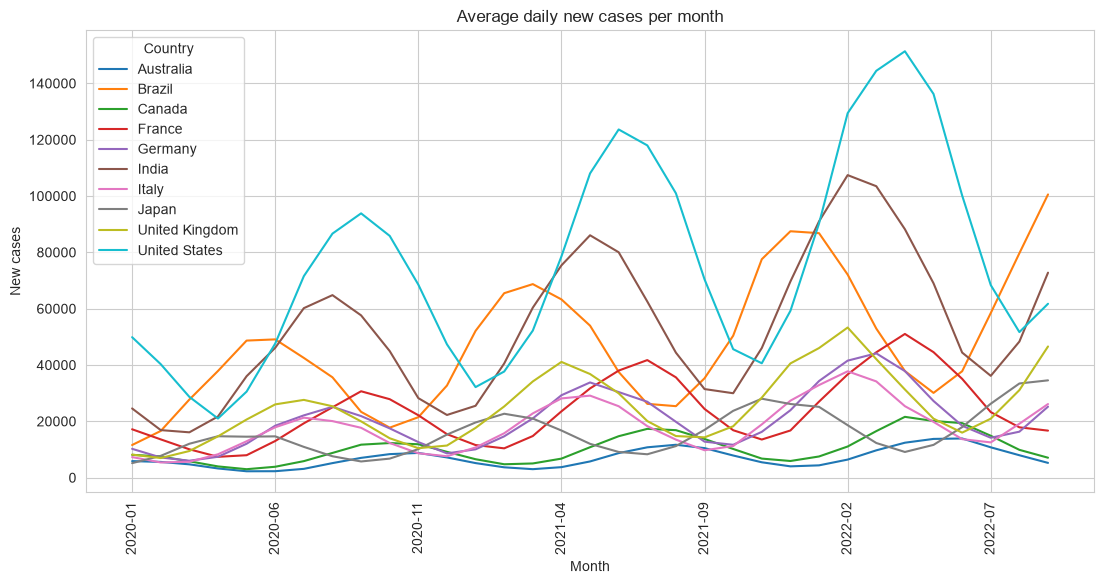

In [ ]:
monthly_cases = df.groupby(['Year_Month', 'Country'])['New_Cases'].mean().unstack()

monthly_cases.plot(figsize=(13, 6))

plt.title('Average daily new cases per month')

plt.xlabel('Month')

plt.ylabel('New cases')

plt.xticks(rotation=90)

plt.show()

### 5.3 Cumulative cases 

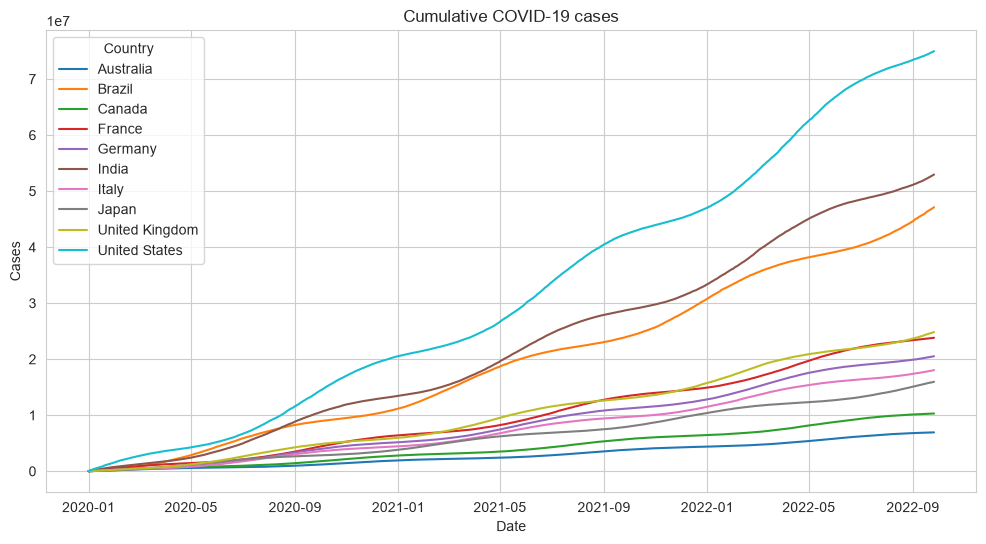

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(x='Date', y='Cumulative_Cases', hue='Country', data=df)

plt.title('Cumulative COVID-19 cases')

plt.ylabel('Cases')

plt.show()

### 5.4 Cumulative deaths 

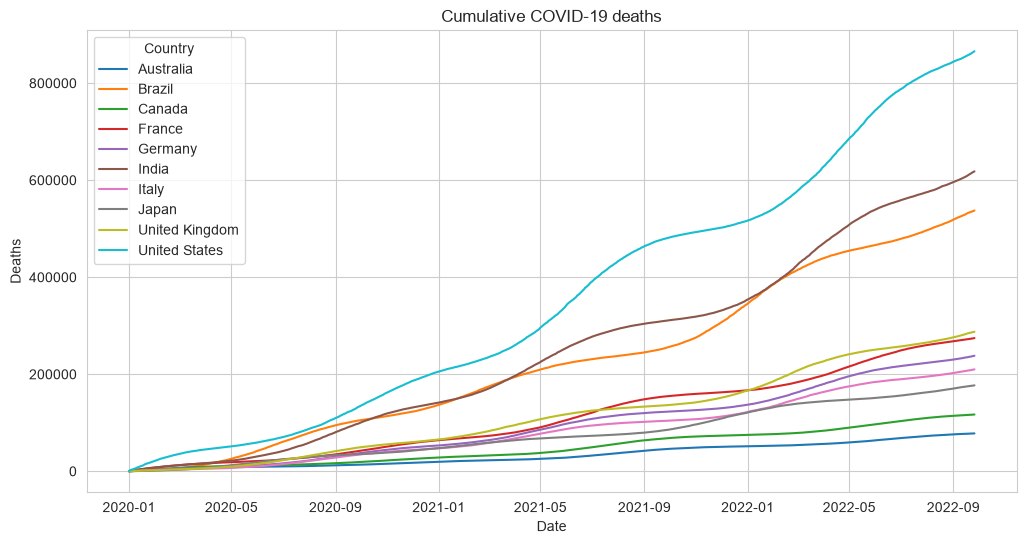

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(x='Date', y='Cumulative_Deaths', hue='Country', data=df)

plt.title('Cumulative COVID-19 deaths')

plt.ylabel('Deaths')

plt.show()

### 5.5 Cumulative vaccine doses

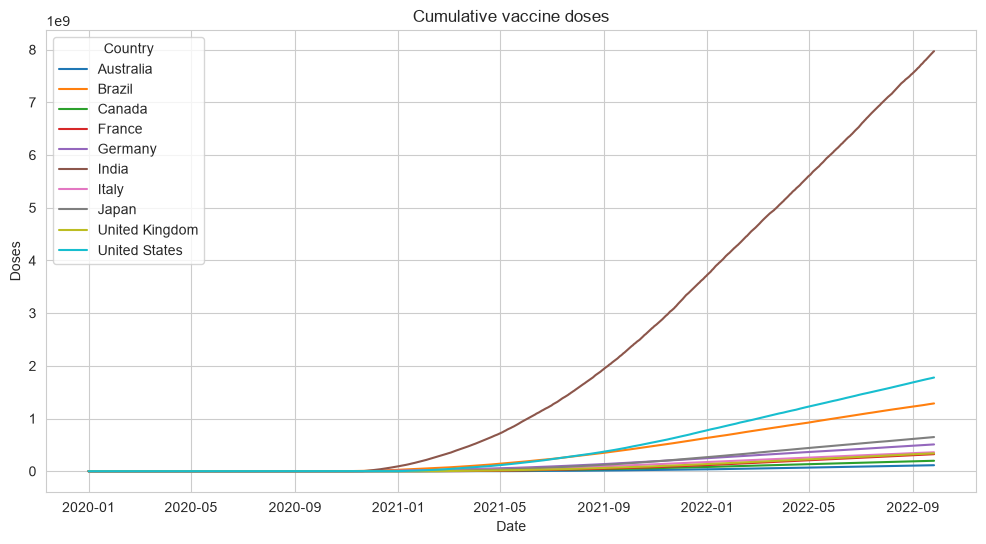

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(x='Date', y='Cumulative_Vaccinations', hue='Country', data=df)

plt.title('Cumulative vaccine doses')

plt.ylabel('Doses')

plt.show()

## 6. Bar charts - compare countries and regions

### 6.1 Total cases 

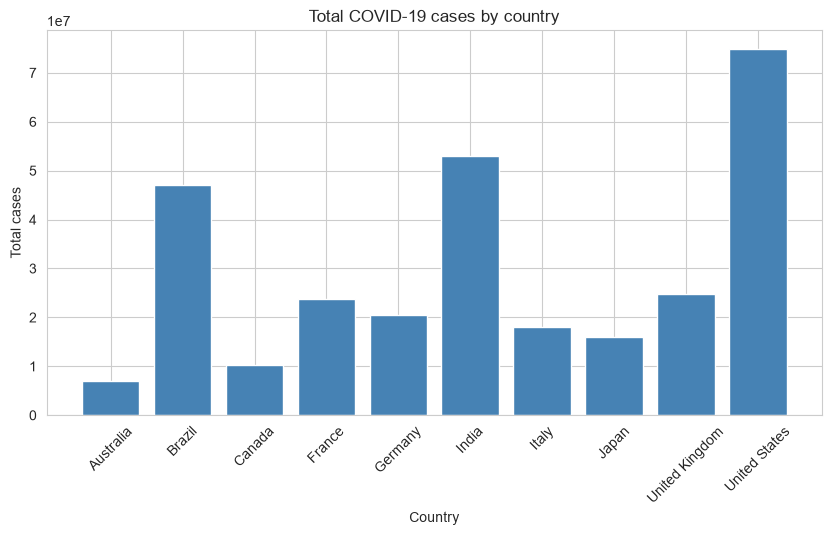

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(last_day['Country'], last_day['Cumulative_Cases'], color='steelblue')

plt.title('Total COVID-19 cases by country')

plt.xlabel('Country')

plt.ylabel('Total cases')

plt.xticks(rotation=45)

plt.show()

### 6.2 Total deaths 

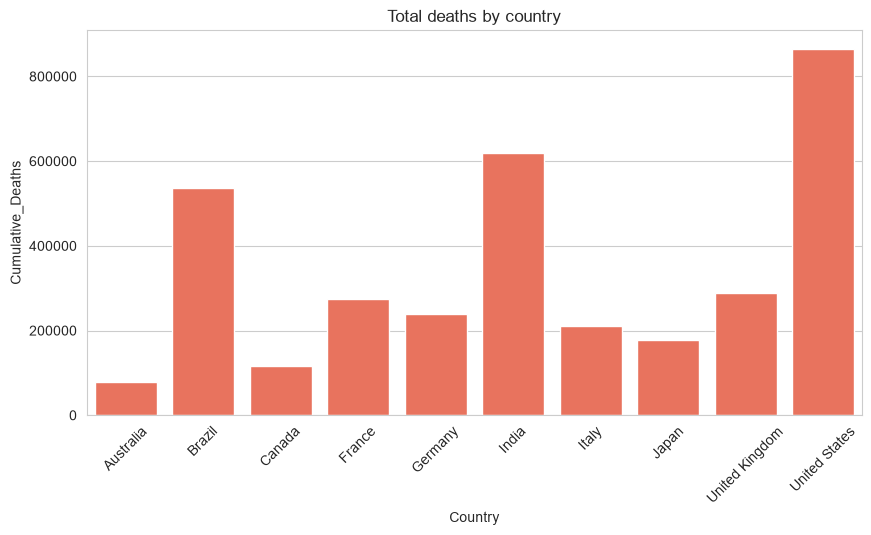

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(x='Country', y='Cumulative_Deaths', data=last_day, color='tomato')

plt.title('Total deaths by country')

plt.xticks(rotation=45)

plt.show()

### 6.3 Total recoveries (Horizontal)

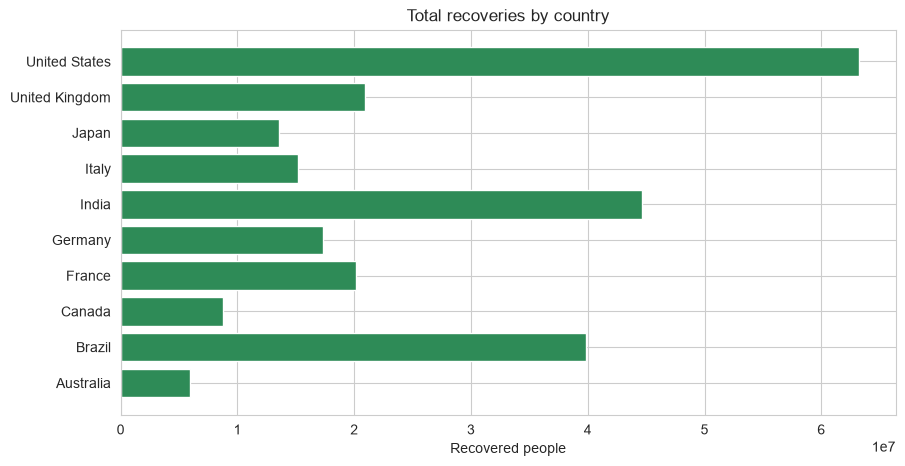

In [ ]:
plt.figure(figsize=(10, 5))

plt.barh(last_day['Country'], last_day['Cumulative_Recovered'], color='seagreen')

plt.title('Total recoveries by country')

plt.xlabel('Recovered people')

plt.show()

### 6.4 Cases per million people



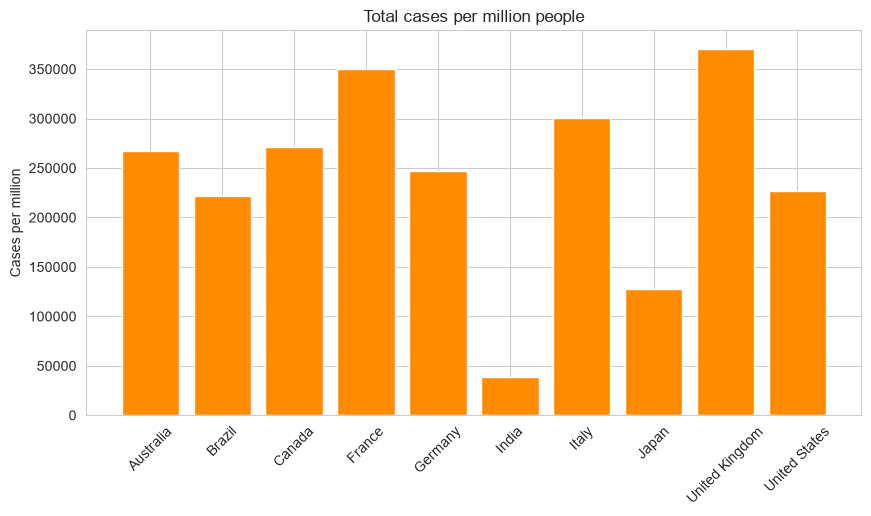

In [ ]:
cases_per_million = last_day['Cumulative_Cases'] / last_day['Population'] * 1000000

plt.figure(figsize=(10, 5))

plt.bar(last_day['Country'], cases_per_million, color='darkorange')

plt.title('Total cases per million people')

plt.ylabel('Cases per million')

plt.xticks(rotation=45)

plt.show()

### 6.5 Total cases by region

Region
Asia             68922043
Europe           87247093
North America    85269626
Oceania           6939510
South America    47133678
Name: Cumulative_Cases, dtype: int64


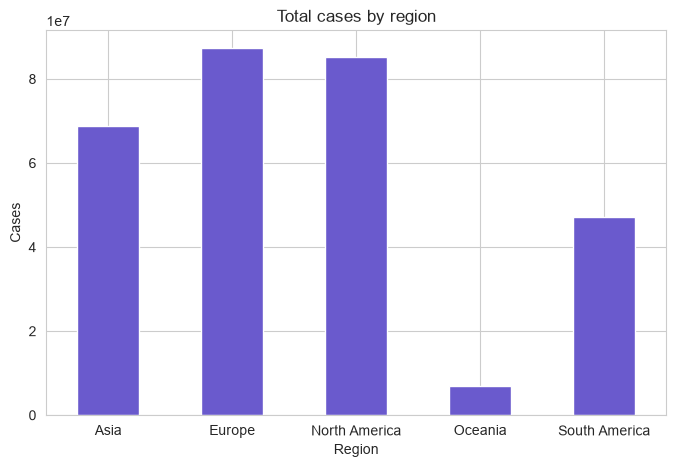

In [ ]:
region_cases = last_day.groupby('Region')['Cumulative_Cases'].sum()

print(region_cases)

region_cases.plot(kind='bar', color='slateblue', figsize=(8, 5))

plt.title('Total cases by region')

plt.ylabel('Cases')

plt.xticks(rotation=0)

plt.show()

## 6. Pie charts - shares of the total

### 6.1 Share of total cases by region

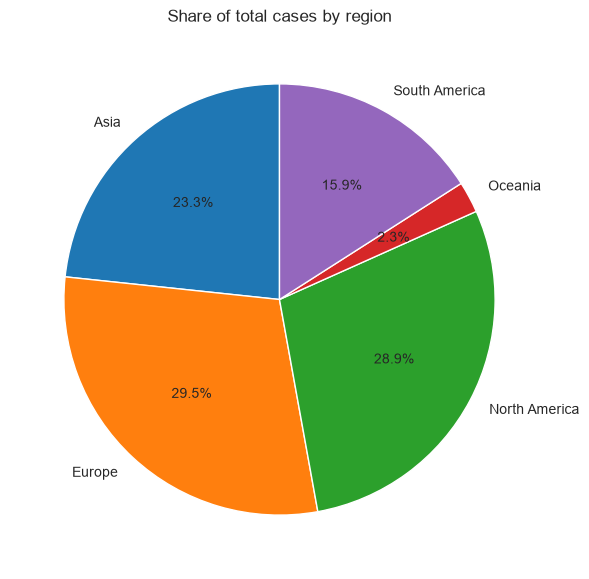

In [ ]:
plt.figure(figsize=(7, 7))

plt.pie(region_cases, labels=region_cases.index, autopct='%1.1f%%', startangle=90)

plt.title('Share of total cases by region')

plt.show()

### 6.2 Share of total deaths by country

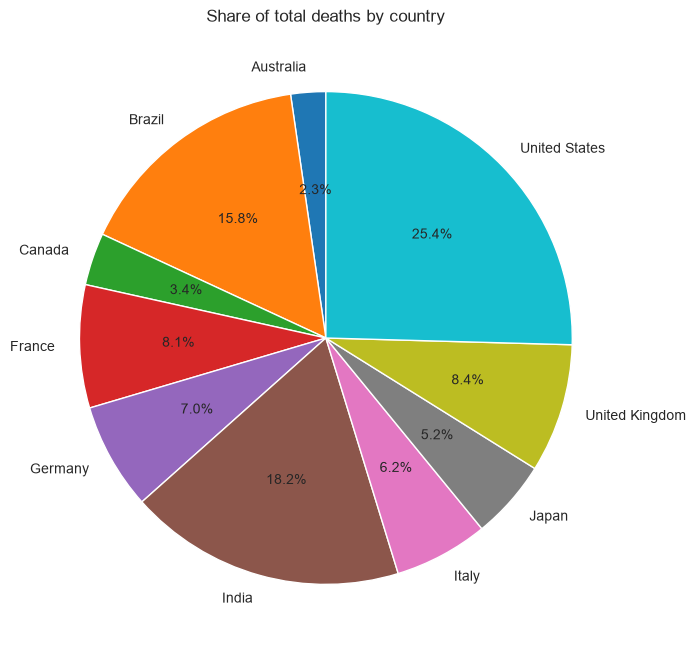

In [ ]:
plt.figure(figsize=(8, 8))

plt.pie(last_day['Cumulative_Deaths'], labels=last_day['Country'], autopct='%1.1f%%', startangle=90)

plt.title('Share of total deaths by country')

plt.show()

### 6.3 What happened to all the cases?

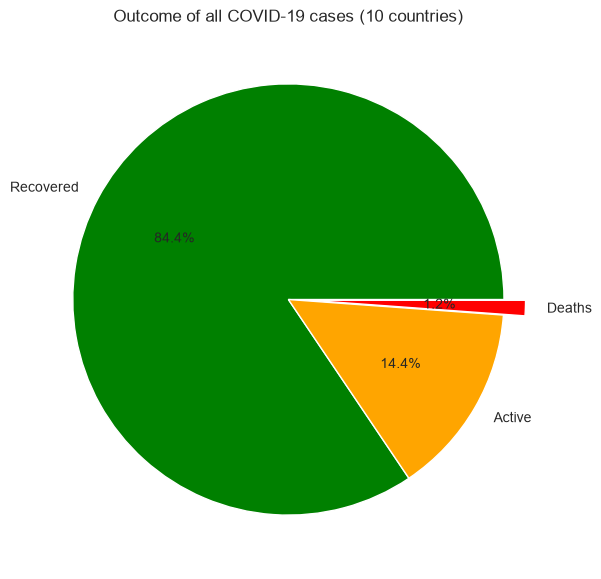

In [ ]:
recovered = last_day['Cumulative_Recovered'].sum()

active = last_day['Active_Cases'].sum()

deaths = last_day['Cumulative_Deaths'].sum()

plt.figure(figsize=(7, 7))

plt.pie([recovered, active, deaths], labels=['Recovered', 'Active', 'Deaths'],
        
        autopct='%1.1f%%', colors=['green', 'orange', 'red'], explode=[0, 0, 0.1])

plt.title('Outcome of all COVID-19 cases (10 countries)')

plt.show()

## 7. Scatter plots - relationship between two numbers

### 7.1 New cases vs. new deaths

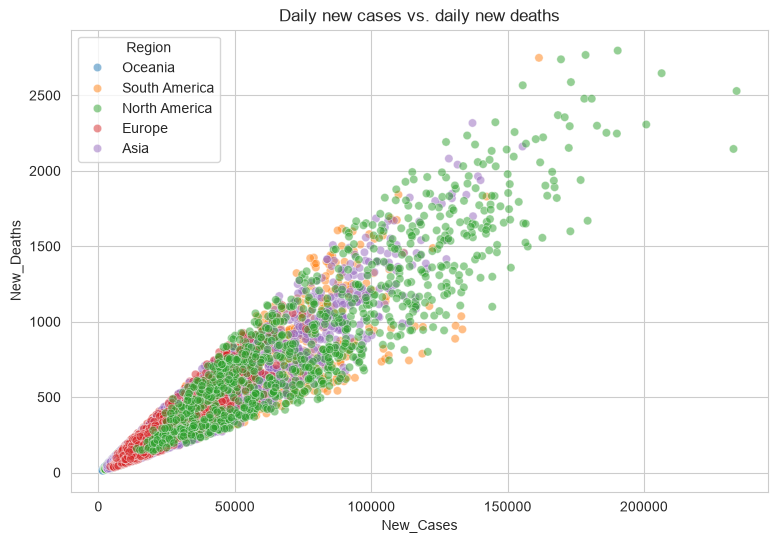

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(x='New_Cases', y='New_Deaths', hue='Region', data=df, alpha=0.5)

plt.title('Daily new cases vs. daily new deaths')

plt.show()

### 7.2 Population vs. total cases 

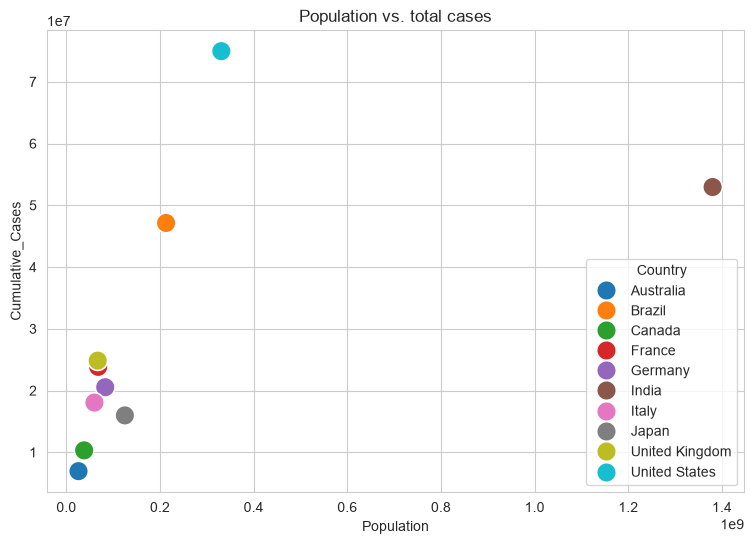

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(x='Population', y='Cumulative_Cases', hue='Country', s=200, data=last_day)

plt.title('Population vs. total cases')

plt.show()

### 7.3 Government intervention score vs. cases per million



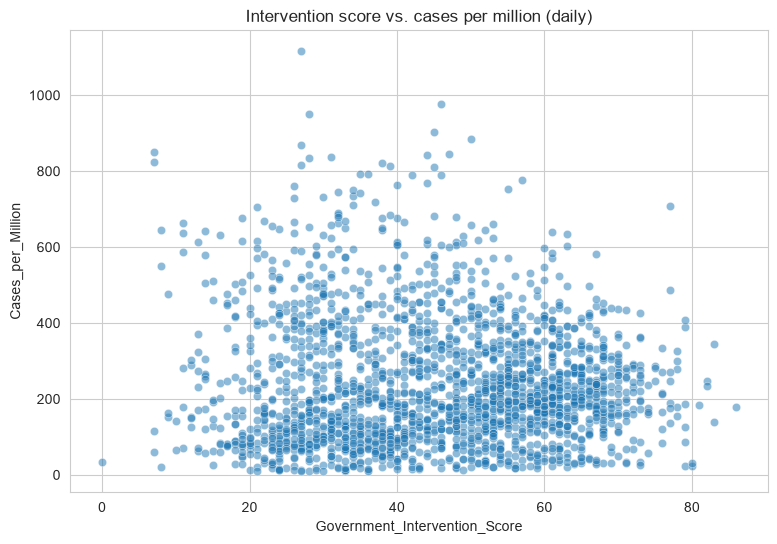

In [ ]:
sample = df.sample(2000, random_state=1)

plt.figure(figsize=(9, 6))

sns.scatterplot(x='Government_Intervention_Score', y='Cases_per_Million', data=sample, alpha=0.5)

plt.title('Intervention score vs. cases per million (daily)')

plt.show()

## 8. Histograms

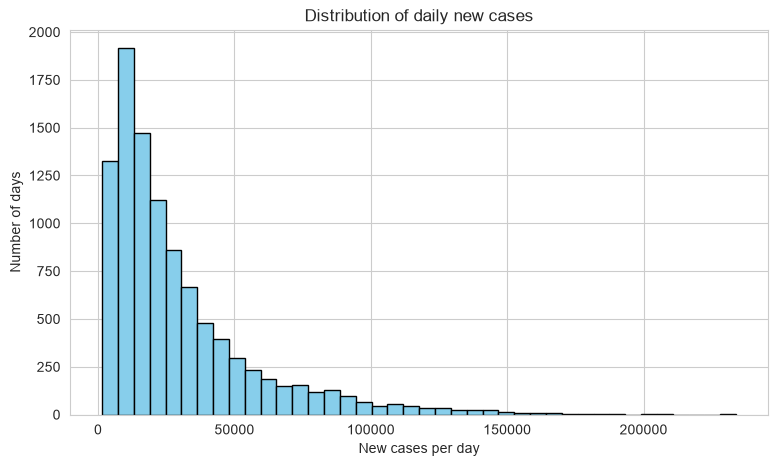

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(df['New_Cases'], bins=40, color='skyblue', edgecolor='black')

plt.title('Distribution of daily new cases')

plt.xlabel('New cases per day')

plt.ylabel('Number of days')

plt.show()

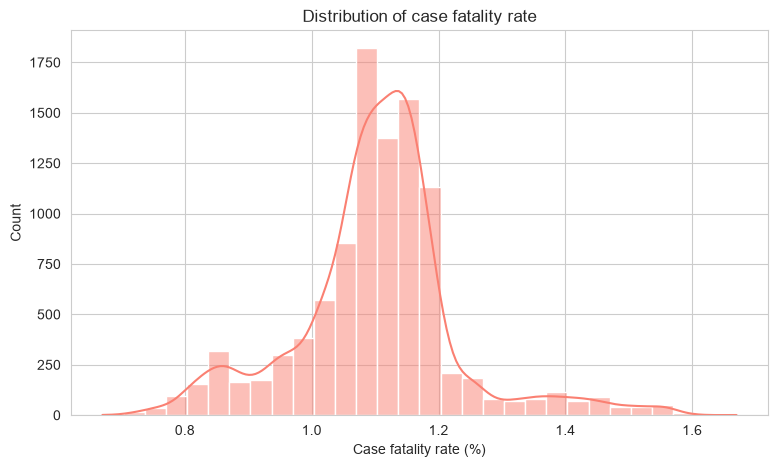

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(df['Case_Fatality_Rate_Percent'], bins=30, kde=True, color='salmon')

plt.title('Distribution of case fatality rate')

plt.xlabel('Case fatality rate (%)')

plt.show()


## 9. Box plots 

### 9.1 Daily new cases in each country

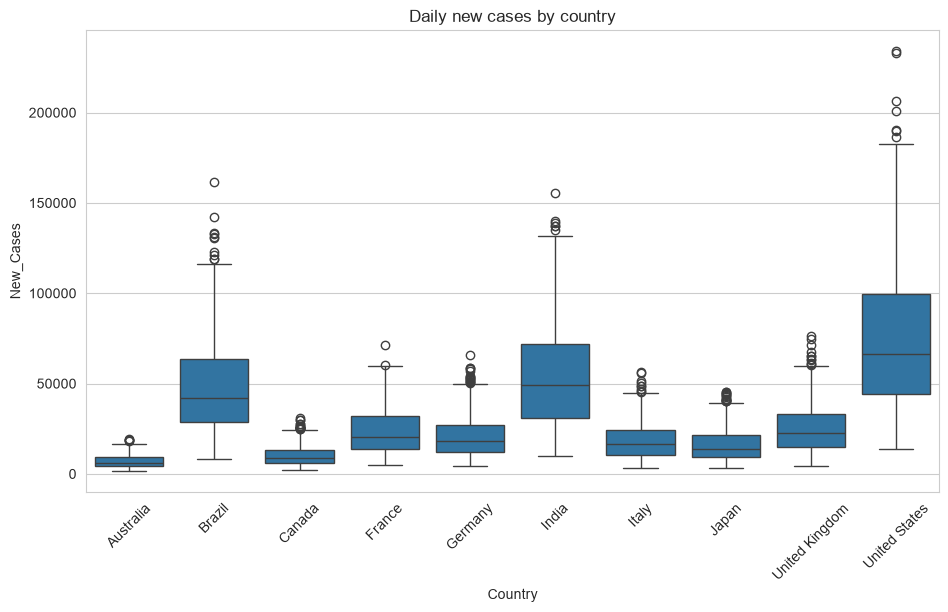

In [ ]:
plt.figure(figsize=(11, 6))

sns.boxplot(x='Country', y='New_Cases', data=df)

plt.title('Daily new cases by country')

plt.xticks(rotation=45)

plt.show()

### 9.2 Case fatality rate in each country

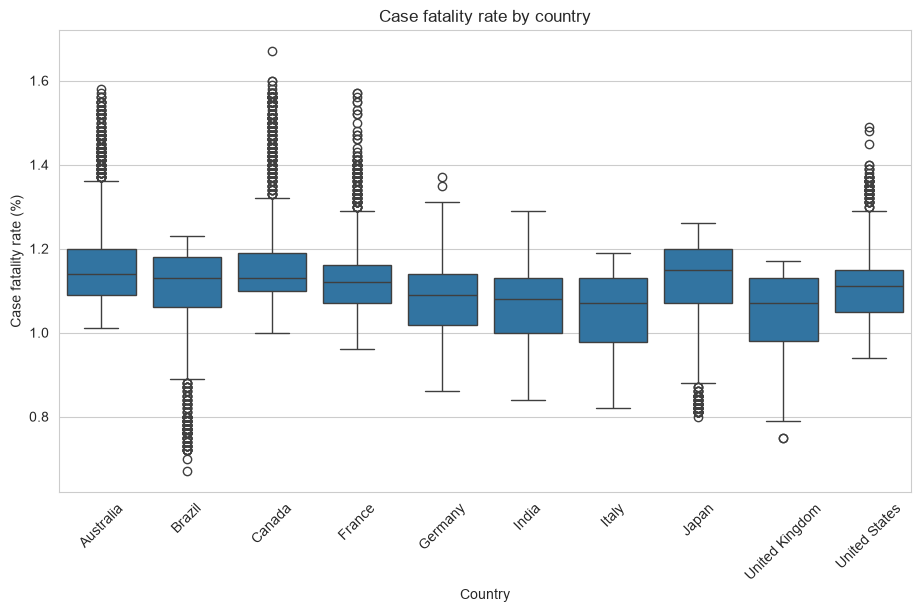

In [104]:
plt.figure(figsize=(11, 6))

sns.boxplot(x='Country', y='Case_Fatality_Rate_Percent', data=df)

plt.title('Case fatality rate by country')

plt.ylabel('Case fatality rate (%)')

plt.xticks(rotation=45)

plt.show()

### 9.3 Cases per million at Low, Medium and High government intervention

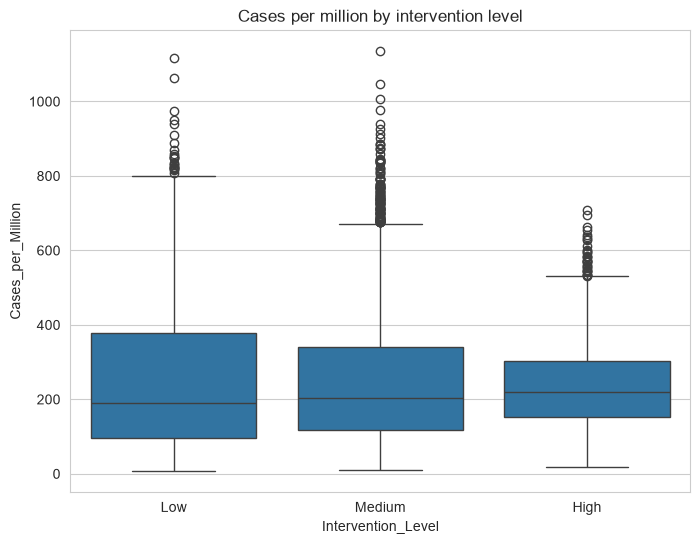

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='Intervention_Level', y='Cases_per_Million', data=df)

plt.title('Cases per million by intervention level')

plt.show()

## 10. Heatmaps 

### 10.1 Correlation heatmap

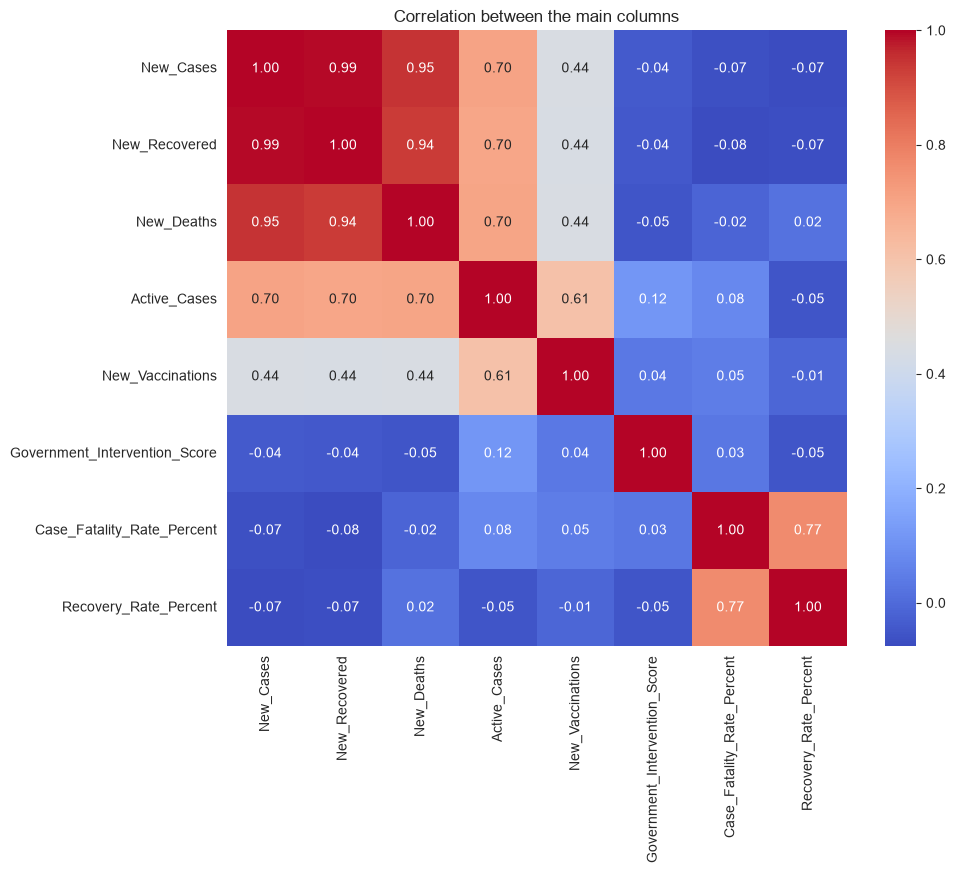

In [ ]:
cols = ['New_Cases', 'New_Recovered', 'New_Deaths', 'Active_Cases', 'New_Vaccinations',
        'Government_Intervention_Score', 'Case_Fatality_Rate_Percent', 'Recovery_Rate_Percent']

plt.figure(figsize=(10, 8))

sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation between the main columns')

plt.show()

### 10.2 Average daily cases per million - Country vs Year

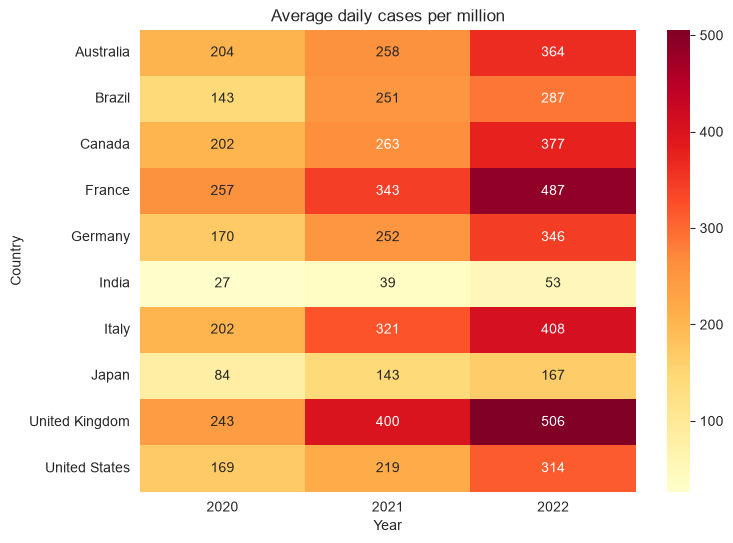

In [ ]:
table = df.pivot_table(index='Country', columns='Year', values='Cases_per_Million', aggfunc='mean')

plt.figure(figsize=(8, 6))

sns.heatmap(table, annot=True, fmt='.0f', cmap='YlOrRd')

plt.title('Average daily cases per million')

plt.show()

### 10.3 Average government intervention score - country vs year

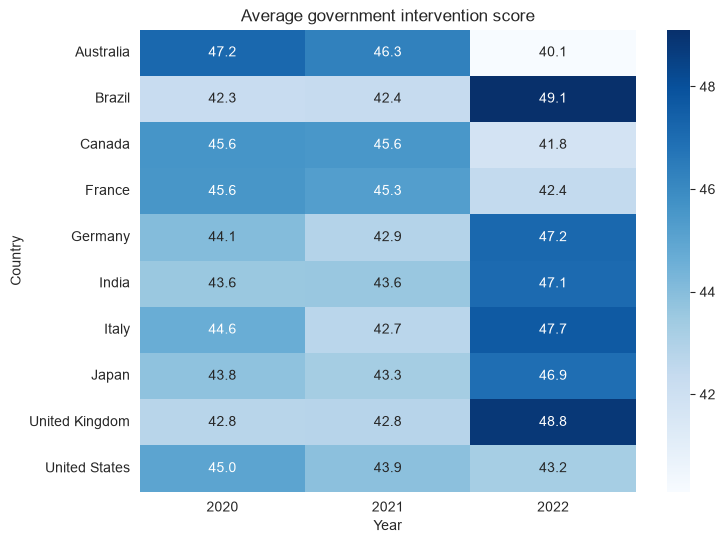

In [ ]:
table = df.pivot_table(index='Country', columns='Year', values='Government_Intervention_Score', aggfunc='mean')

plt.figure(figsize=(8, 6))

sns.heatmap(table, annot=True, fmt='.1f', cmap='Blues')

plt.title('Average government intervention score')

plt.show()

### 11 What happened to cases in the NEXT month?



In [ ]:
# monthly average of cases and intervention score for every country
monthly = df.groupby(['Country', 'Year_Month'])[['New_Cases', 'Government_Intervention_Score']].mean().reset_index()



# cases in the next month (for the same country)
monthly['Cases_Next_Month'] = monthly.groupby('Country')['New_Cases'].shift(-1)



# % change from this month to next month
monthly['Change_Percent'] = (monthly['Cases_Next_Month'] - monthly['New_Cases']) / monthly['New_Cases'] * 100



# three equal groups: Low, Medium, High
monthly['Level'] = pd.qcut(monthly['Government_Intervention_Score'], 3, labels=['Low', 'Medium', 'High'])



# the last month of every country has no "next month", so remove it
monthly = monthly.dropna()

monthly.head()

,Country,Year_Month,New_Cases,Government_Intervention_Score,Cases_Next_Month,Change_Percent,Level
0,Australia,2020-01,5874.903226,64.645161,5587.724138,-4.888235,High
1,Australia,2020-02,5587.724138,65.000000,4726.129032,-15.419428,High
2,Australia,2020-03,4726.129032,55.903226,3262.066667,-30.978045,High
3,Australia,2020-04,3262.066667,39.800000,2267.096774,-30.501213,Medium
4,Australia,2020-05,2267.096774,33.419355,2287.733333,0.910264,Low


             mean     median
Level                       
Low     28.733201  32.636547
Medium   5.562222   4.928599
High   -13.182076 -21.033406


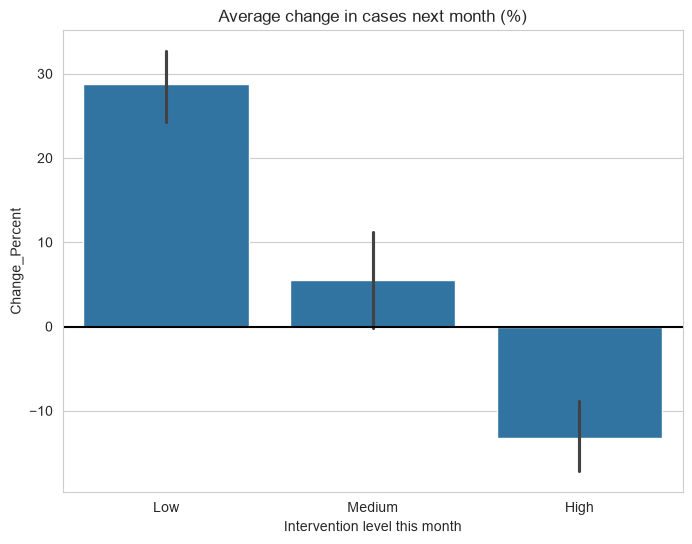

In [ ]:
print(monthly.groupby('Level')['Change_Percent'].agg(['mean', 'median']))

plt.figure(figsize=(8, 6))

sns.barplot(x='Level', y='Change_Percent', data=monthly)

plt.axhline(0, color='black')

plt.title('Average change in cases next month (%)')

plt.xlabel('Intervention level this month')

plt.show()

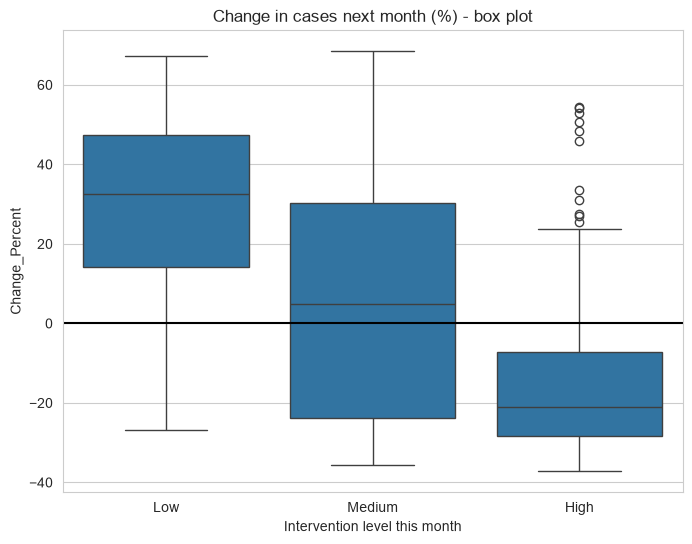

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='Level', y='Change_Percent', data=monthly)

plt.axhline(0, color='black')

plt.title('Change in cases next month (%) - box plot')

plt.xlabel('Intervention level this month')

plt.show()

## 12. Summary numbers

In [ ]:
total_cases = last_day['Cumulative_Cases'].sum()
total_recovered = last_day['Cumulative_Recovered'].sum()
total_deaths = last_day['Cumulative_Deaths'].sum()



print('Total cases       :', total_cases)

print('Total recoveries  :', total_recovered, '(', round(total_recovered / total_cases * 100, 1), '% of cases )')

print('Total deaths      :', total_deaths, '(', round(total_deaths / total_cases * 100, 2), '% of cases )')

print()

print('Most total cases        :', last_day.loc[last_day['Cumulative_Cases'].idxmax(), 'Country'])

print('Most cases per million  :', last_day.loc[cases_per_million.idxmax(), 'Country'])

print('Fewest cases per million:', last_day.loc[cases_per_million.idxmin(), 'Country'])

print('Region with most cases  :', region_cases.idxmax())

Total cases       : 295511950
Total recoveries  : 249533663 ( 84.4 % of cases )
Total deaths      : 3403611 ( 1.15 % of cases )

Most total cases        : United States
Most cases per million  : United Kingdom
Fewest cases per million: India
Region with most cases  : Europe
